Author: Malcolm Zartman

Sharable Link: https://colab.research.google.com/drive/1O-5um_US2mJCwa0_NGfY1XgDUSCsO9kU?usp=sharing


In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.layers import Embedding
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
# output directory name:
output_dir = 'model_output/dense' # Store model's parameters after each epoch, useful at a later time

# training:
epochs = 10 # Number of epochs
batch_size = 64 # number of training examples used during each round of model training

# vector-space embedding:
n_dim = 128 # The number of dimensions we'd like our word-vector space to have
n_unique_words = 10000 # sort all of the tokens by the number of times in corpus, used top 5000
n_words_to_skip = 50 # 50 most frequently occurring words across corpus serve as a decent list of stop words
max_review_length = 250 # review length, short add padding, more truncate
pad_type = trunc_type = 'pre'

# neural network architecture:
n_dense = 256 # The number of neurons to include in the dense layer of our neural network architecture.
dropout = 0.3 # How much dropout to apply to the neurons in the dense layer

In [ ]:
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words, # 50k reviews, 25k train, 25k validating
                                                        skip_top=n_words_to_skip) # 4 or less, y=0; 7 or more, y = 1, ignore rest.

# 0 reserved for padding; 1 would be starting character; 2 is unknown; 3 is most common word, etc.
x_train[0:6]

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([list([2, 2, 2, 2, 2, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 2, 173, 2, 256, 2, 2, 100, 2, 838, 112, 50, 670, 2, 2, 2, 480, 284, 2, 150, 2, 172, 112, 167, 2, 336, 385, 2, 2, 172, 4536, 1111, 2, 546, 2, 2, 447, 2, 192, 50, 2, 2, 147, 2025, 2, 2, 2, 2, 1920, 4613, 469, 2, 2, 71, 87, 2, 2, 2, 530, 2, 76, 2, 2, 1247, 2, 2, 2, 515, 2, 2, 2, 626, 2, 2, 2, 62, 386, 2, 2, 316, 2, 106, 2, 2, 2223, 5244, 2, 480, 66, 3785, 2, 2, 130, 2, 2, 2, 619, 2, 2, 124, 51, 2, 135, 2, 2, 1415, 2, 2, 2, 2, 215, 2, 77, 52, 2, 2, 407, 2, 82, 2, 2, 2, 107, 117, 5952, 2, 256, 2, 2, 2, 3766, 2, 723, 2, 71, 2, 530, 476, 2, 400, 317, 2, 2, 2, 2, 1029, 2, 104, 88, 2, 381, 2, 297, 98, 2, 2071, 56, 2, 141, 2, 194, 7486, 2, 2, 226, 2, 2, 134, 476, 2, 480, 2, 144, 2, 5535, 2, 51, 2, 2, 224, 92, 2, 104, 2, 226, 65, 2, 2, 1334, 88, 2, 2, 283, 2, 2, 4472, 113, 103, 2, 2, 2, 5345, 2, 178, 2]),
       list([2, 194, 1153, 194, 8255, 78, 228, 2, 2, 1463, 4369, 5012, 134, 2, 2, 715, 2, 118, 1634, 2, 394, 2, 2, 119,

In [ ]:
for x in x_train[0:6]:
    print(len(x))

218
189
141
550
147
43


In [ ]:
y_train[0:6]

array([1, 0, 0, 1, 0, 0])

In [ ]:
len(x_train), len(x_valid)

(25000, 25000)

In [ ]:
word_index = keras.datasets.imdb.get_word_index()
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["PAD"] = 0
word_index["START"] = 1
word_index["UNK"] = 2

word_index

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


{'fawn': 34704,
 'tsukino': 52009,
 'nunnery': 52010,
 'sonja': 16819,
 'vani': 63954,
 'woods': 1411,
 'spiders': 16118,
 'hanging': 2348,
 'woody': 2292,
 'trawling': 52011,
 "hold's": 52012,
 'comically': 11310,
 'localized': 40833,
 'disobeying': 30571,
 "'royale": 52013,
 "harpo's": 40834,
 'canet': 52014,
 'aileen': 19316,
 'acurately': 52015,
 "diplomat's": 52016,
 'rickman': 25245,
 'arranged': 6749,
 'rumbustious': 52017,
 'familiarness': 52018,
 "spider'": 52019,
 'hahahah': 68807,
 "wood'": 52020,
 'transvestism': 40836,
 "hangin'": 34705,
 'bringing': 2341,
 'seamier': 40837,
 'wooded': 34706,
 'bravora': 52021,
 'grueling': 16820,
 'wooden': 1639,
 'wednesday': 16821,
 "'prix": 52022,
 'altagracia': 34707,
 'circuitry': 52023,
 'crotch': 11588,
 'busybody': 57769,
 "tart'n'tangy": 52024,
 'burgade': 14132,
 'thrace': 52026,
 "tom's": 11041,
 'snuggles': 52028,
 'francesco': 29117,
 'complainers': 52030,
 'templarios': 52128,
 '272': 40838,
 '273': 52031,
 'zaniacs': 52133,

In [ ]:
index_word = {v:k for k,v in word_index.items()}

x_train[0]

[2,
 2,
 2,
 2,
 2,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 2,
 173,
 2,
 256,
 2,
 2,
 100,
 2,
 838,
 112,
 50,
 670,
 2,
 2,
 2,
 480,
 284,
 2,
 150,
 2,
 172,
 112,
 167,
 2,
 336,
 385,
 2,
 2,
 172,
 4536,
 1111,
 2,
 546,
 2,
 2,
 447,
 2,
 192,
 50,
 2,
 2,
 147,
 2025,
 2,
 2,
 2,
 2,
 1920,
 4613,
 469,
 2,
 2,
 71,
 87,
 2,
 2,
 2,
 530,
 2,
 76,
 2,
 2,
 1247,
 2,
 2,
 2,
 515,
 2,
 2,
 2,
 626,
 2,
 2,
 2,
 62,
 386,
 2,
 2,
 316,
 2,
 106,
 2,
 2,
 2223,
 5244,
 2,
 480,
 66,
 3785,
 2,
 2,
 130,
 2,
 2,
 2,
 619,
 2,
 2,
 124,
 51,
 2,
 135,
 2,
 2,
 1415,
 2,
 2,
 2,
 2,
 215,
 2,
 77,
 52,
 2,
 2,
 407,
 2,
 82,
 2,
 2,
 2,
 107,
 117,
 5952,
 2,
 256,
 2,
 2,
 2,
 3766,
 2,
 723,
 2,
 71,
 2,
 530,
 476,
 2,
 400,
 317,
 2,
 2,
 2,
 2,
 1029,
 2,
 104,
 88,
 2,
 381,
 2,
 297,
 98,
 2,
 2071,
 56,
 2,
 141,
 2,
 194,
 7486,
 2,
 2,
 226,
 2,
 2,
 134,
 476,
 2,
 480,
 2,
 144,
 2,
 5535,
 2,
 51,
 2,
 2,
 224,
 92,
 2,
 104,
 2,
 226,
 65,
 2,
 2,
 1

In [ ]:
' '.join(index_word[id] for id in x_train[0])

"UNK UNK UNK UNK UNK brilliant casting location scenery story direction everyone's really suited UNK part UNK played UNK UNK could UNK imagine being there robert UNK UNK UNK amazing actor UNK now UNK same being director UNK father came UNK UNK same scottish island UNK myself UNK UNK loved UNK fact there UNK UNK real connection UNK UNK UNK UNK witty remarks throughout UNK UNK were great UNK UNK UNK brilliant UNK much UNK UNK bought UNK UNK UNK soon UNK UNK UNK released UNK UNK UNK would recommend UNK UNK everyone UNK watch UNK UNK fly fishing UNK amazing really cried UNK UNK end UNK UNK UNK sad UNK UNK know what UNK say UNK UNK cry UNK UNK UNK UNK must UNK been good UNK UNK definitely UNK also UNK UNK UNK two little boy's UNK played UNK UNK UNK norman UNK paul UNK were UNK brilliant children UNK often left UNK UNK UNK UNK list UNK think because UNK stars UNK play them UNK grown up UNK such UNK big profile UNK UNK whole UNK UNK these children UNK amazing UNK should UNK praised UNK what U

In [ ]:
(all_x_train,_),(all_x_valid,_) = imdb.load_data()
' '.join(index_word[id] for id in all_x_train[0])

"START this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [ ]:
x_train = pad_sequences(x_train, maxlen=max_review_length,
                        padding=pad_type, truncating=trunc_type, value=0)
x_valid = pad_sequences(x_valid, maxlen=max_review_length,
                        padding=pad_type, truncating=trunc_type, value=0)

x_train[0:6]

array([[   0,    0,    0, ...,    2,  178,    2],
       [   0,    0,    0, ...,    2,  145,   95],
       [   0,    0,    0, ...,    2,  129,  113],
       [   2,    2,    2, ...,    2,   64, 2574],
       [   0,    0,    0, ...,    2,   61,  113],
       [   0,    0,    0, ...,    2,    2,    2]], dtype=int32)

In [ ]:
for x in x_train[0:6]:
    print(len(x))

' '.join(index_word[id] for id in x_train[0])

250
250
250
250
250
250


"PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD UNK UNK UNK UNK UNK brilliant casting location scenery story direction everyone's really suited UNK part UNK played UNK UNK could UNK imagine being there robert UNK UNK UNK amazing actor UNK now UNK same being director UNK father came UNK UNK same scottish island UNK myself UNK UNK loved UNK fact there UNK UNK real connection UNK UNK UNK UNK witty remarks throughout UNK UNK were great UNK UNK UNK brilliant UNK much UNK UNK bought UNK UNK UNK soon UNK UNK UNK released UNK UNK UNK would recommend UNK UNK everyone UNK watch UNK UNK fly fishing UNK amazing really cried UNK UNK end UNK UNK UNK sad UNK UNK know what UNK say UNK UNK cry UNK UNK UNK UNK must UNK been good UNK UNK definitely UNK also UNK UNK UNK two little boy's UNK played UNK UNK UNK norman UNK paul UNK were UNK brilliant children UNK often left UNK UNK UNK UNK list UNK think because UNK stars UNK pl

In [ ]:
' '.join(index_word[id] for id in x_train[5])

'PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD PAD UNK begins better than UNK ends funny UNK UNK russian submarine crew UNK UNK other actors UNK UNK those scenes where documentary shots UNK UNK spoiler part UNK message UNK

In [ ]:
model = Sequential() # Each layer flows to the next

#1st hidden layer
model.add(Embedding(input_dim=n_unique_words, output_dim=n_dim, input_shape=(max_review_length,))) # 5k by 64 dim matrix
model.add(Flatten()) # takes multi-dim input and produce one dim output, dense layer only accept 1d inputs

#2nd hidden layer: 64 dim relu activation layer
model.add(Dense(n_dense, activation='relu'))
model.add(Dropout(dropout))

#3rd hidden layer if needed more,
model.add(Dense(n_dense, activation='relu'))
model.add(Dropout(dropout))

#Output layer: Single sigmoid neuron to predict binary classification
model.add(Dense(1, activation='sigmoid')) # mathematically equivalent to softmax with two classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,538,305 (36.39 MB)

 Trainable params: 9,538,305 (36.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
n_dim, n_unique_words, n_dim * n_unique_words

(128, 10000, 1280000)

In [ ]:
max_review_length,n_dim,n_dim*max_review_length

(250, 128, 32000)

In [ ]:
n_dense,n_dim*max_review_length+n_dense+n_dense

(256, 32512)

In [ ]:
n_dense+1

257

In [ ]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=['accuracy'])

#allow to save our model parameters after each epoch during training
modelcheckpoint = ModelCheckpoint(filepath=output_dir + "/model_epoch_{epoch:02d}.keras")

In [ ]:
import os
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

history = model.fit(x_train, y_train,
                    batch_size=batch_size, epochs=epochs, verbose=1,
                    validation_data=(x_valid, y_valid),
                    callbacks=[modelcheckpoint])

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5147 - loss: 0.6932 - val_accuracy: 0.5302 - val_loss: 0.6895
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7388 - loss: 0.5150 - val_accuracy: 0.8475 - val_loss: 0.3524
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9158 - loss: 0.2175 - val_accuracy: 0.8706 - val_loss: 0.3095
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9770 - loss: 0.0826 - val_accuracy: 0.8532 - val_loss: 0.3939
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9959 - loss: 0.0239 - val_accuracy: 0.8624 - val_loss: 0.4228
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9991 - loss: 0.0077 - val_accuracy: 0.8598 - val_loss: 0.4940
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9997 - loss: 0.0031 - val_accuracy: 0.8619 - val_loss: 0.5206
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 

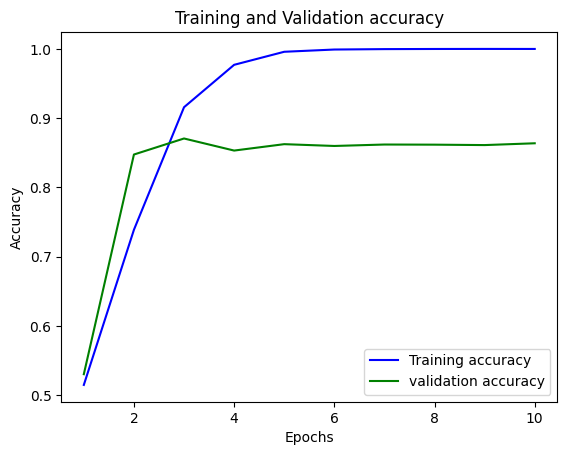

In [ ]:
# Plotting Accuracy
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs_range = range(1, len(loss_train) + 1)
plt.plot(epochs_range, loss_train, 'b', label='Training accuracy')
plt.plot(epochs_range, loss_val, 'g', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

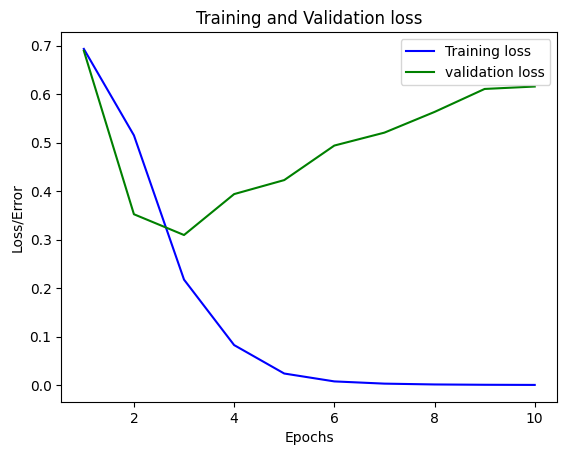

In [ ]:
# Plotting Loss
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs_range = range(1, len(loss_train) + 1)
plt.plot(epochs_range, loss_train, 'b', label='Training loss')
plt.plot(epochs_range, loss_val, 'g', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

In [ ]:
model.load_weights(output_dir+"/model_epoch_02.keras") # load the epoch 1 weights, NOT zero-indexed

In [ ]:
y_hat = model.predict(x_valid)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [ ]:
len(y_hat)

25000

In [ ]:
y_hat[0]

array([0.37910923], dtype=float32)

In [ ]:
int(y_valid[0])

0

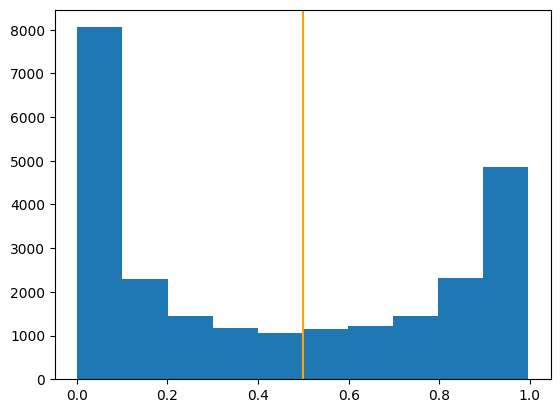

In [ ]:
plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')

In [ ]:
pct_auc = roc_auc_score(y_valid, y_hat)*100.0

In [ ]:
"{:0.2f}".format(pct_auc)

'93.15'

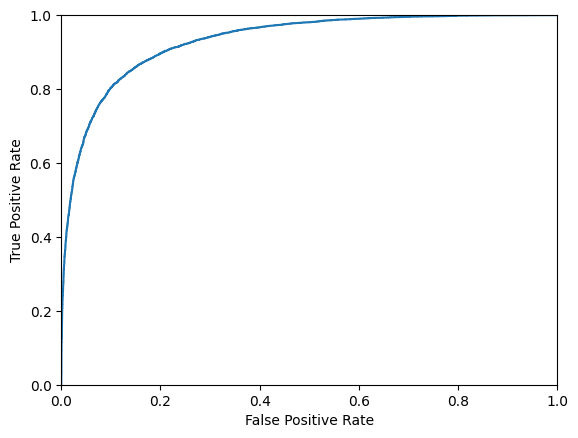

In [ ]:
fpr,tpr,thresholds = roc_curve(y_valid, y_hat)
plt.plot(fpr, tpr)
plt.axis([0,1,0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
float_y_hat = []
for y in y_hat:
    float_y_hat.append(y[0])

ydf = pd.DataFrame(list(zip(float_y_hat, y_valid)), columns=['y_hat', 'y'])

ydf.head(10)


,y_hat,y
0,0.379109,0
1,0.950295,1
2,0.355608,1
3,0.371347,0
4,0.968688,1
5,0.605782,1
6,0.572361,1
7,0.070431,0
8,0.857005,0
9,0.761573,1


In [ ]:
' '.join(index_word[id] for id in all_x_valid[0])

"START please give this one a miss br br kristy swanson and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite lacklustre so all you madison fans give this a miss"

In [ ]:
' '.join(index_word[id] for id in all_x_valid[6])

"START originally supposed to be just a part of a huge epic the year 1905 depicting the revolution of 1905 potemkin is the story of the mutiny of the crew of the potemkin in odessa harbor the film opens with the crew protesting meat and the captain ordering the execution of the an uprising takes place during which the revolutionary leader is killed this crewman is taken to the shore to lie in state when the townspeople gather on a huge flight of steps overlooking the harbor czarist troops appear and march down the steps breaking up the crowd a naval squadron is sent to retake the potemkin but at the moment when the ships come into range their crews allow the to pass through eisenstein's non historically accurate ending is open ended thus indicating that this was the seed of the later bolshevik revolution that would bloom in russia the film is broken into five parts men and maggots drama on the an appeal from the dead the odessa steps and meeting the squadron br br eisenstein was a revo

In [ ]:
ydf[(ydf.y == 0) & (ydf.y_hat > 0.9)].head(10)

,y_hat,y
256,0.926217,0
386,0.901745,0
447,0.908329,0
778,0.906785,0
781,0.941046,0
814,0.902892,0
1059,0.940003,0
1207,0.952167,0
1593,0.924442,0
1803,0.948991,0


In [ ]:
' '.join(index_word[id] for id in all_x_valid[75])

"START the adventures of hercules has to be one of the lamest excuses for a movie i've yet run across you would have to look far and wide to find anything that approaches the level of ineptness on display in this movie acting \x96 bad editing \x96 bad direction \x96 bad special effects \x96 bad and laughable plot \x96 bad lighting \x96 bad cinematography \x96 bad costume design \x96 bad and silly everything else \x96 bad watching the adventures of hercules is about as enjoyable as a root canal even for a fan of bad movies it's a real endurance test this is one for either masochists or lou ferrigno completists if any exist br br eight things i learned from watching the adventures of hercules br br 1 if you don't have the budget for real special effects rotoscope a scene from the previous movie it will look great trust me br br 2 when on a quest to recover take time for frequent stops to oil up you body it worked for ferrigno and his two amazon companions br br 3 any sword fight use of m

In [ ]:
ydf[(ydf.y == 1) & (ydf.y_hat < 0.1)].head(10)

,y_hat,y
101,0.091937,1
187,0.046357,1
224,0.082579,1
227,0.079090,1
248,0.060168,1
263,0.070659,1
298,0.072131,1
300,0.060949,1
325,0.052780,1
345,0.053135,1


In [ ]:
' '.join(index_word[id] for id in all_x_valid[80])

"START with the obvious exception of fools horses this was in my opinion david jason's finest series br br coming straight after his tv debut on 'do not adjust your set ' these 13 episodes revealed a mastery of comic timing not seen since the old silent movie days by comparison porridge open all hours and that awful series 'lucky man' did not come close br br i believe jason banned the series being repeated because it showed him at his rawest shame on him a new generation deserves to enjoy this the series actually flopped in the ratings but that is most likely because it was shown against 'the brothers' which aired on bbc at the same time before vcrs were commonplace br br btw i have only just noticed that his long suffering assistant spencer was played by mark eden alan bradley off coronation street i am amazed he didn't try to murder edgar briggs"